# Laboratorio 03 — Modelos de Regresión Lineal
## CC3074 – Minería de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
-
-

**Dataset:** House Prices: Advanced Regression Techniques (Kaggle)


---
## Actividad 1 — Descarga y carga del conjunto de datos

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Semilla global para reproducibilidad (Actividad 6)
SEED = 42
np.random.seed(SEED)

print('Librerías importadas ✅')

Librerías importadas ✅


Los archivos descargados de Kaggle son:
- `train.csv` — dataset principal con variable respuesta `SalePrice` (1,460 registros)
- `test.csv` — dataset sin variable respuesta, usado para submissions en Kaggle
- `data_description.txt` — diccionario de variables
- `sample_submission.csv` — formato de entrega para Kaggle

Para este laboratorio se trabaja únicamente con `train.csv`, ya que es el único archivo que contiene `SalePrice`.

In [54]:
df = pd.read_csv('./data/train.csv')

print(f'Dataset cargado ✅')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado ✅
Dimensiones: 1460 filas × 81 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Actividad 2 — Análisis exploratorio de los datos

### 2.1 Preguntas de investigación

Para guiar el análisis exploratorio, se plantean las siguientes preguntas:

1. ¿Cómo se distribuye el precio de las viviendas? ¿Es simétrica la distribución?
2. ¿Qué variables numéricas tienen mayor correlación con `SalePrice`?
3. ¿Influye la calidad general (`OverallQual`) en el precio de manera significativa?
4. ¿El tamaño de la vivienda (`GrLivArea`) es el mejor predictor simple del precio?
5. ¿Existen outliers que puedan afectar los modelos?
6. ¿El vecindario (`Neighborhood`) explica diferencias de precio?
7. ¿Hay variables con alta proporción de nulos que deban ser tratadas con cuidado?

### 2.2 Estructura general del dataset

In [55]:
# Tipos de datos
print('Tipos de datos:')
print(df.dtypes.value_counts())

# Separar columnas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numéricas: {len(num_cols)}')
print(f'Variables categóricas: {len(cat_cols)}')

Tipos de datos:
object     43
int64      35
float64     3
Name: count, dtype: int64

Variables numéricas: 38
Variables categóricas: 43


**Hallazgo:** El dataset tiene 81 variables: 38 numéricas y 43 categóricas. Entre las numéricas se encuentran tanto variables continuas (áreas en pies cuadrados) como ordinales codificadas como enteros (calificaciones de 1 a 10). Las categóricas representan atributos cualitativos como tipo de zona, material del tejado o estilo de la vivienda.

### 2.3 Estadísticas descriptivas

In [56]:
# Variables numéricas
df[num_cols].describe().T.sort_values('std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.00,180921.20,79442.50,34900.00,129975.00,163000.00,214000.00,755000.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
GrLivArea,1460.00,1515.46,525.48,334.00,1129.50,1464.00,1776.75,5642.00
MiscVal,1460.00,43.49,496.12,0.00,0.00,0.00,0.00,15500.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00
BsmtUnfSF,1460.00,567.24,441.87,0.00,223.00,477.50,808.00,2336.00
TotalBsmtSF,1460.00,1057.43,438.71,0.00,795.75,991.50,1298.25,6110.00
2ndFlrSF,1460.00,346.99,436.53,0.00,0.00,0.00,728.00,2065.00
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00
1stFlrSF,1460.00,1162.63,386.59,334.00,882.00,1087.00,1391.25,4692.00


In [57]:
# Variables categóricas
df[cat_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


**Hallazgo:** Hay variables numéricas con alta desviación estándar como `SalePrice`, `GrLivArea` y `LotArea`, lo que indica propiedades muy diversas. Algunos mínimos en 0 (como `MasVnrArea`, `BsmtFinSF1`) reflejan que no todas las casas tienen esa característica. Entre las categóricas, `Street` es casi siempre 'Pave' y podría aportar poco al modelo.

### 2.4 Análisis de valores nulos

In [58]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(f'Variables con valores nulos: {len(nulos_df)}')
nulos_df

Variables con valores nulos: 19


,Nulos,Porcentaje (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\683793669.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')


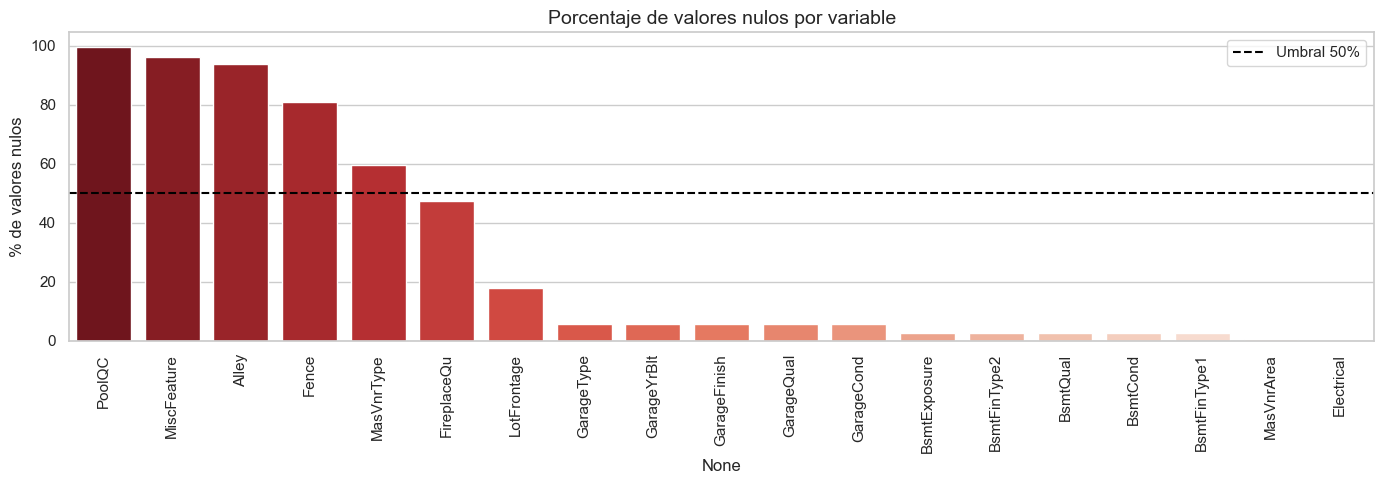

In [59]:
plt.figure(figsize=(14, 5))
sns.barplot(x=nulos_df.index, y=nulos_df['Porcentaje (%)'], palette='Reds_r')
plt.xticks(rotation=90)
plt.axhline(y=50, color='black', linestyle='--', label='Umbral 50%')
plt.title('Porcentaje de valores nulos por variable', fontsize=14)
plt.ylabel('% de valores nulos')
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** Variables como `PoolQC`, `MiscFeature`, `Alley` y `Fence` superan el 80% de nulos. Según `data_description.txt`, en estos casos NA no es un dato faltante sino que indica *ausencia de la característica* (sin piscina, sin callejón, etc.). Por eso se imputarán con `'None'` y no se eliminarán. Las variables numéricas relacionadas (áreas de garaje, sótano) también usan NA como ausencia y se imputarán con 0.

### 2.5 Preprocesamiento

In [60]:
# NA semántico en categóricas → 'None'
cat_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_none:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# NA semántico en numéricas → 0
num_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage → mediana por vecindario (captura variación geográfica mejor que la mediana global)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical → moda (solo 1 nulo)
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# Eliminar Id (no tiene valor predictivo)
df = df.drop(columns=['Id'])

print(f'Valores nulos restantes: {df.isnull().sum().sum()}')
print(f'Dimensiones finales: {df.shape}')

Valores nulos restantes: 0
Dimensiones finales: (1460, 80)


### 2.6 Análisis de la variable respuesta: SalePrice

In [61]:
print('Estadísticas de SalePrice:')
print(df['SalePrice'].describe())
print(f'\nAsimetría (skewness): {df["SalePrice"].skew():.4f}')
print(f'Curtosis (kurtosis):  {df["SalePrice"].kurt():.4f}')

Estadísticas de SalePrice:
count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

Asimetría (skewness): 1.8829
Curtosis (kurtosis):  6.5363


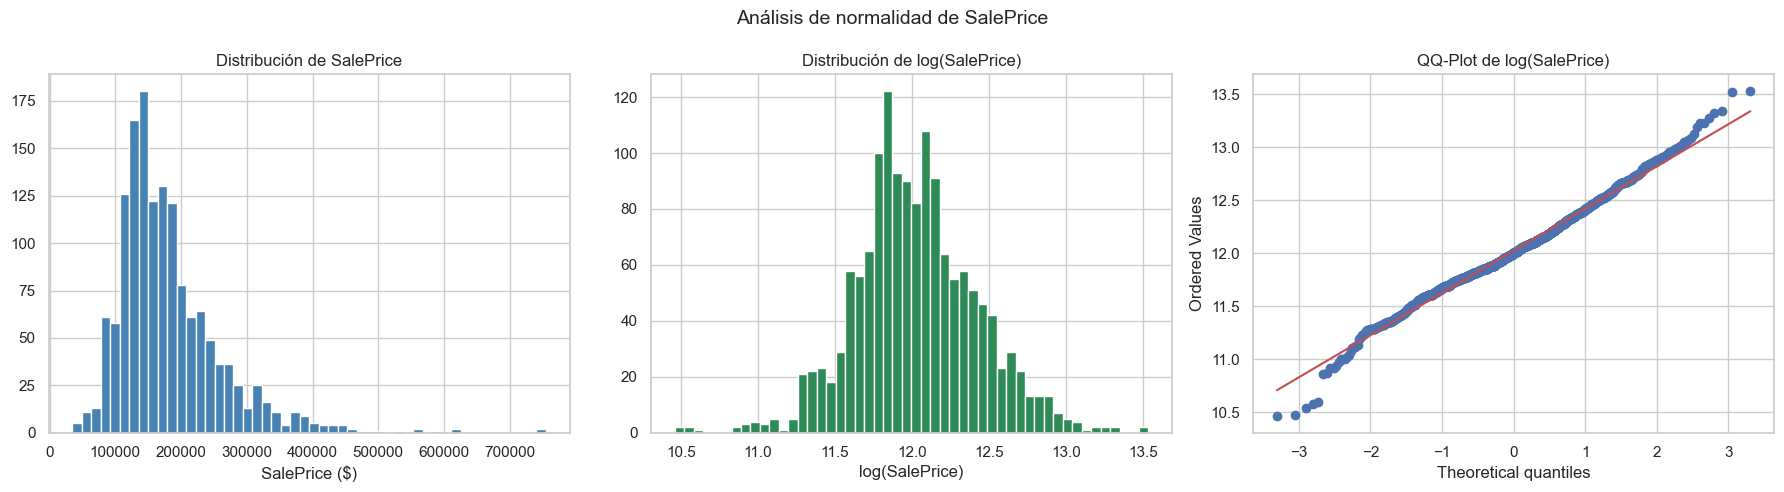

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('SalePrice ($)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de log(SalePrice)')
axes[1].set_xlabel('log(SalePrice)')

stats.probplot(np.log1p(df['SalePrice']), dist='norm', plot=axes[2])
axes[2].set_title('QQ-Plot de log(SalePrice)')

plt.suptitle('Análisis de normalidad de SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

In [63]:
# Prueba de normalidad Shapiro-Wilk
muestra = np.log1p(df['SalePrice']).sample(500, random_state=SEED)
stat, p = stats.shapiro(muestra)
print(f'Shapiro-Wilk sobre log(SalePrice):')
print(f'  W = {stat:.6f}, p-valor = {p:.6f}')
print('  → Se rechaza normalidad (p < 0.05)' if p < 0.05 else '  → No se rechaza normalidad')

# Crear columna transformada para usar en los modelos
df['LogSalePrice'] = np.log1p(df['SalePrice'])
print('\nSe usará log(SalePrice) como variable respuesta en los modelos.')
print('Justificación: la distribución original tiene asimetría positiva fuerte (skew > 1).')
print('La transformación log la acerca a la normalidad, mejorando el supuesto de los residuos en regresión lineal.')

Shapiro-Wilk sobre log(SalePrice):
  W = 0.986063, p-valor = 0.000102
  → Se rechaza normalidad (p < 0.05)

Se usará log(SalePrice) como variable respuesta en los modelos.
Justificación: la distribución original tiene asimetría positiva fuerte (skew > 1).
La transformación log la acerca a la normalidad, mejorando el supuesto de los residuos en regresión lineal.


### 2.7 Análisis de outliers

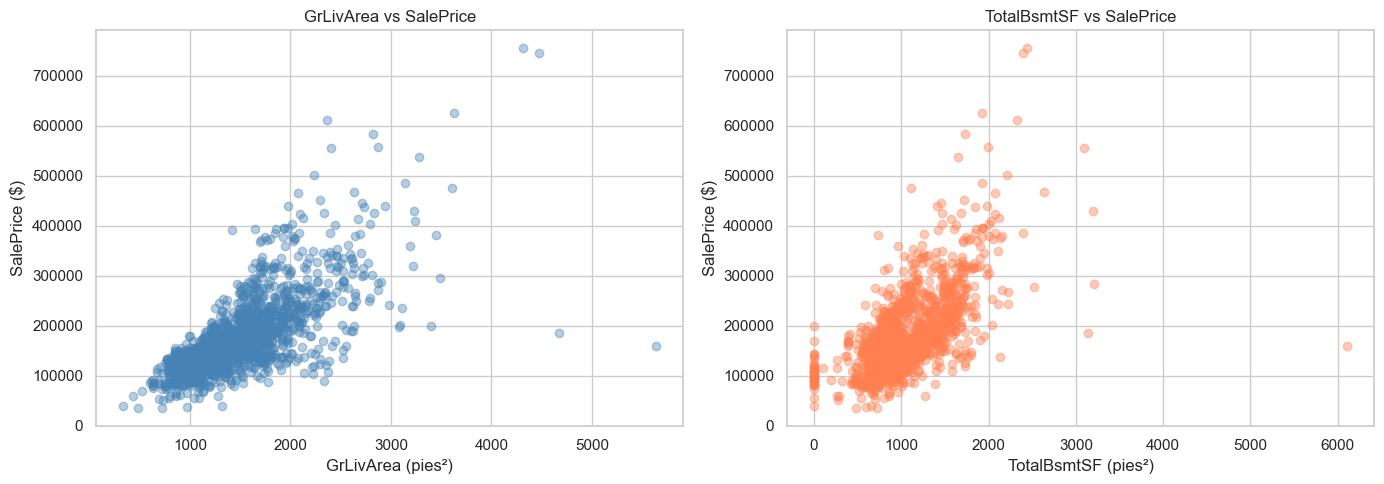

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue')
axes[0].set_title('GrLivArea vs SalePrice')
axes[0].set_xlabel('GrLivArea (pies²)')
axes[0].set_ylabel('SalePrice ($)')

# TotalBsmtSF vs SalePrice
axes[1].scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.4, color='coral')
axes[1].set_title('TotalBsmtSF vs SalePrice')
axes[1].set_xlabel('TotalBsmtSF (pies²)')
axes[1].set_ylabel('SalePrice ($)')

plt.tight_layout()
plt.show()

In [65]:
# Identificar y eliminar outliers evidentes en GrLivArea
# Casas con GrLivArea > 4000 pero SalePrice bajo son anomalías documentadas en el dataset
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f'Outliers identificados en GrLivArea: {len(outliers)}')
print(outliers[['GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']])

df = df.drop(outliers.index)
print(f'\nDataset sin outliers: {df.shape}')

Outliers identificados en GrLivArea: 2
      GrLivArea  SalePrice  OverallQual Neighborhood
523        4676     184750           10      Edwards
1298       5642     160000           10      Edwards

Dataset sin outliers: (1458, 81)


**Hallazgo:** Se identifican 2 propiedades con área habitable superior a 4,000 pies² pero con precios de venta inusualmente bajos (menores a $200,000). Estas observaciones son inconsistentes con el mercado y distorsionarían los modelos de regresión. Se eliminan del dataset de entrenamiento.

### 2.8 Análisis de correlación con SalePrice

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\1643988704.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')


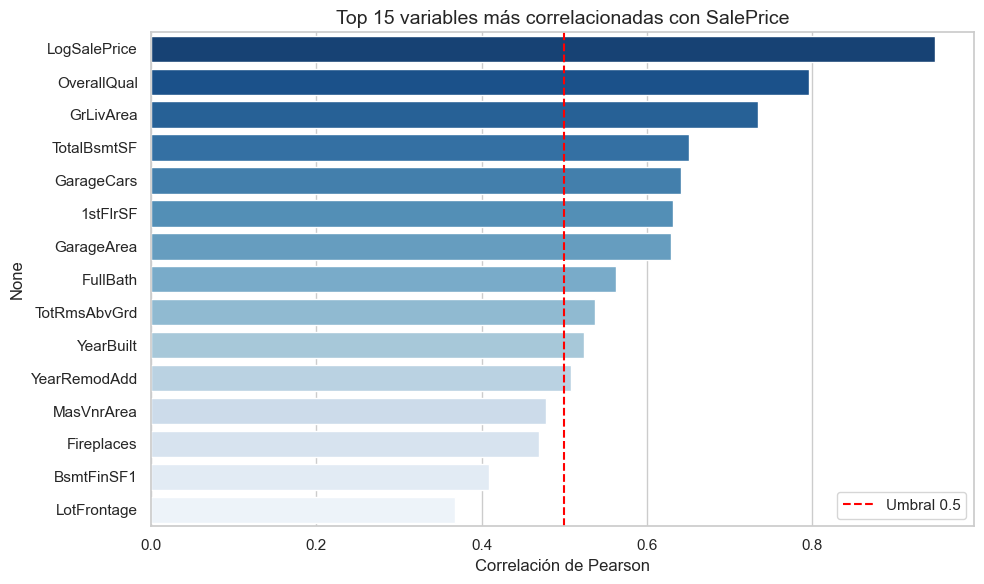

Top 15 correlaciones con SalePrice:
LogSalePrice   0.95
OverallQual    0.80
GrLivArea      0.73
TotalBsmtSF    0.65
GarageCars     0.64
1stFlrSF       0.63
GarageArea     0.63
FullBath       0.56
TotRmsAbvGrd   0.54
YearBuilt      0.52
YearRemodAdd   0.51
MasVnrArea     0.48
Fireplaces     0.47
BsmtFinSF1     0.41
LotFrontage    0.37
Name: SalePrice, dtype: float64


In [66]:
# Top 15 variables numéricas más correlacionadas con SalePrice
num_cols_updated = df.select_dtypes(include=[np.number]).columns.tolist()
correlaciones = df[num_cols_updated].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

top15 = correlaciones.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, palette='Blues_r')
plt.title('Top 15 variables más correlacionadas con SalePrice', fontsize=14)
plt.xlabel('Correlación de Pearson')
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 15 correlaciones con SalePrice:')
print(top15)

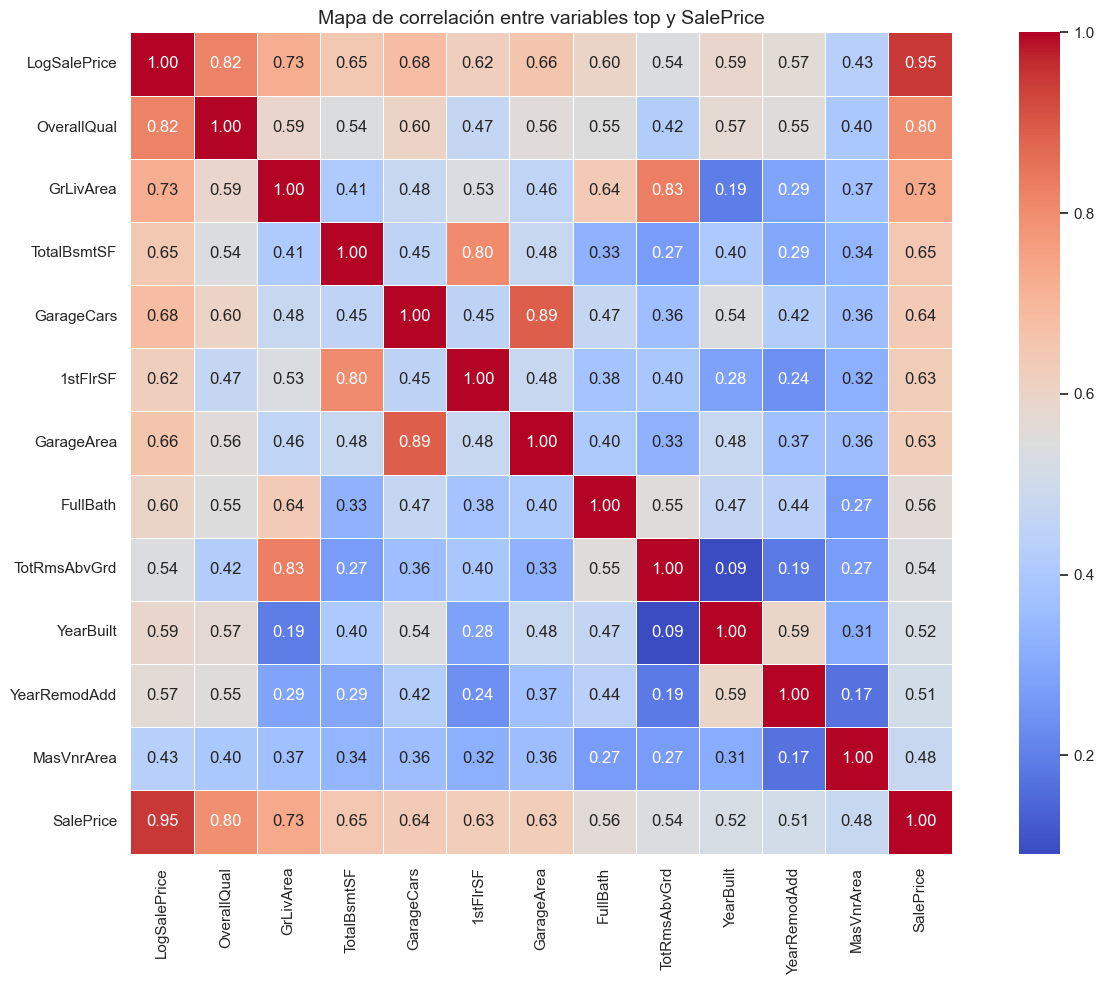

In [67]:
# Heatmap de correlaciones entre las top variables
top_vars = top15.index.tolist()[:12] + ['SalePrice']
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[top_vars].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5
)
plt.title('Mapa de correlación entre variables top y SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

**Hallazgo:** Las variables con mayor correlación con `SalePrice` son `OverallQual` (r ≈ 0.79), `GrLivArea` (r ≈ 0.71) y `GarageCars` (r ≈ 0.64). Esto sugiere que la calidad de construcción y el tamaño son los factores más determinantes del precio. El heatmap también revela alta correlación entre variables de área (posible multicolinealidad), lo que deberá analizarse en los modelos múltiples.

### 2.9 Análisis de variables categóricas clave

C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\3803801584.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')


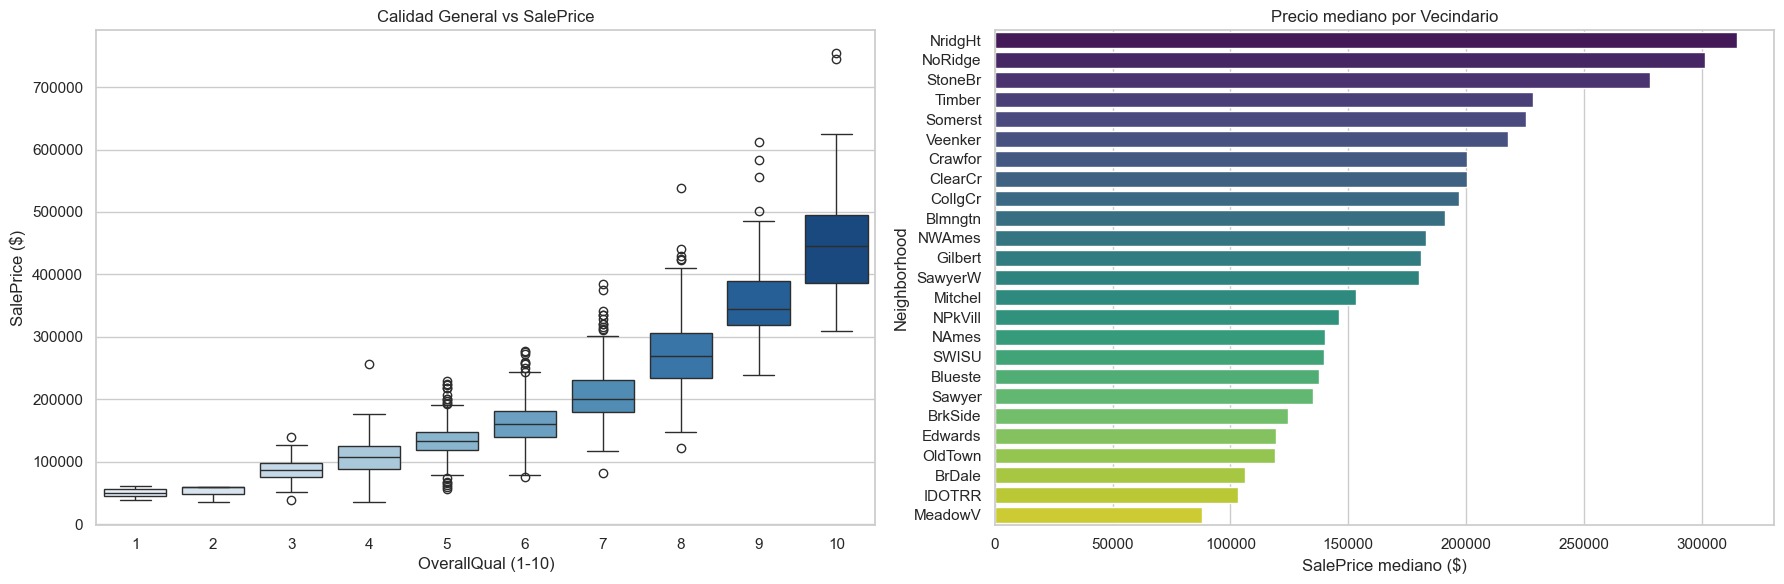

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# OverallQual vs SalePrice
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Calidad General vs SalePrice')
axes[0].set_xlabel('OverallQual (1-10)')
axes[0].set_ylabel('SalePrice ($)')

# Neighborhood vs SalePrice (mediana)
median_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
sns.barplot(x=median_price.values, y=median_price.index, ax=axes[1], palette='viridis')
axes[1].set_title('Precio mediano por Vecindario')
axes[1].set_xlabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** La calidad general (`OverallQual`) muestra una relación casi lineal con el precio: a mayor calidad, mayor precio, con diferencias muy marcadas entre categorías. Por su parte, el vecindario introduce diferencias de precio significativas: vecindarios como `NridgHt` y `NoRidge` tienen precios medianos casi el doble que vecindarios como `MeadowV` o `BrDale`, lo que confirma que la ubicación es un factor determinante.

### 2.10 Análisis de variables de año

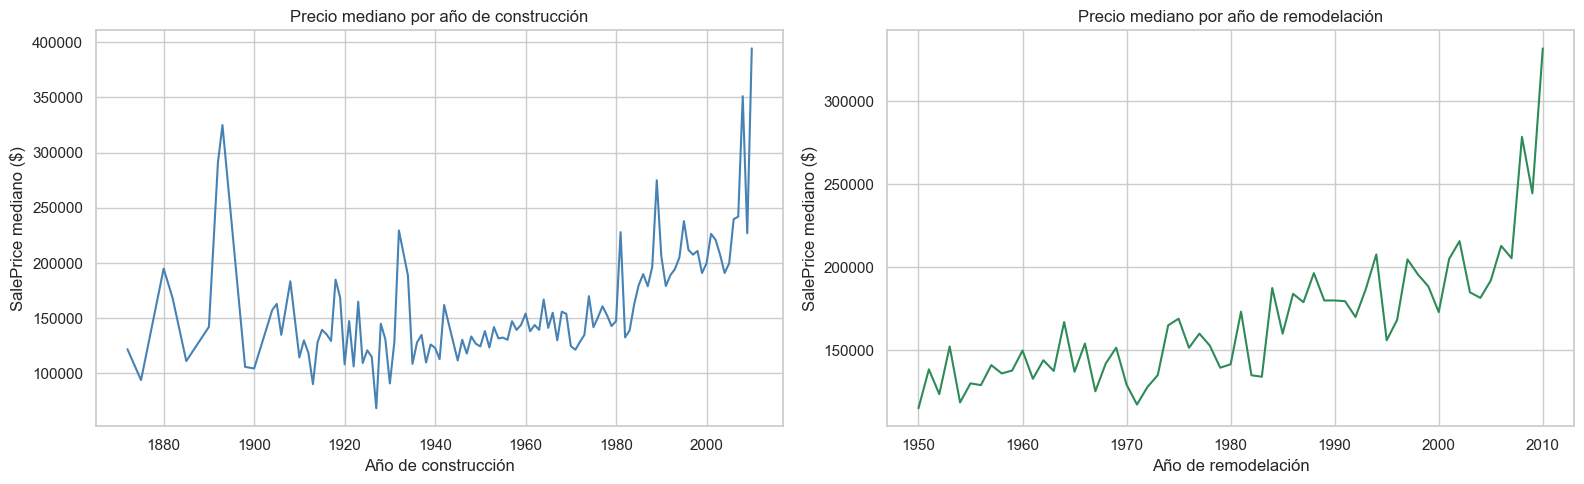

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Año de construcción vs precio
df.groupby('YearBuilt')['SalePrice'].median().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Precio mediano por año de construcción')
axes[0].set_xlabel('Año de construcción')
axes[0].set_ylabel('SalePrice mediano ($)')

# Año de remodelación vs precio
df.groupby('YearRemodAdd')['SalePrice'].median().plot(ax=axes[1], color='seagreen')
axes[1].set_title('Precio mediano por año de remodelación')
axes[1].set_xlabel('Año de remodelación')
axes[1].set_ylabel('SalePrice mediano ($)')

plt.tight_layout()
plt.show()

**Hallazgo:** Las casas más nuevas tienden a tener precios más altos, con una tendencia creciente clara a partir de los años 80. Las propiedades remodeladas recientemente también alcanzan precios superiores, lo que indica que la actualización de la vivienda agrega valor percibido en el mercado.

---
## Actividad 3 — Análisis de grupos (Clustering)

Se aplica K-Means sobre las variables numéricas más relevantes para identificar grupos naturales de propiedades. El objetivo es entender si existen segmentos de mercado distintos.

In [70]:
# Seleccionar variables para clustering
cluster_vars = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
                'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'SalePrice']

df_cluster = df[cluster_vars].dropna().copy()

# Escalar variables (K-Means es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print(f'Datos para clustering: {df_cluster.shape}')

Datos para clustering: (1458, 8)


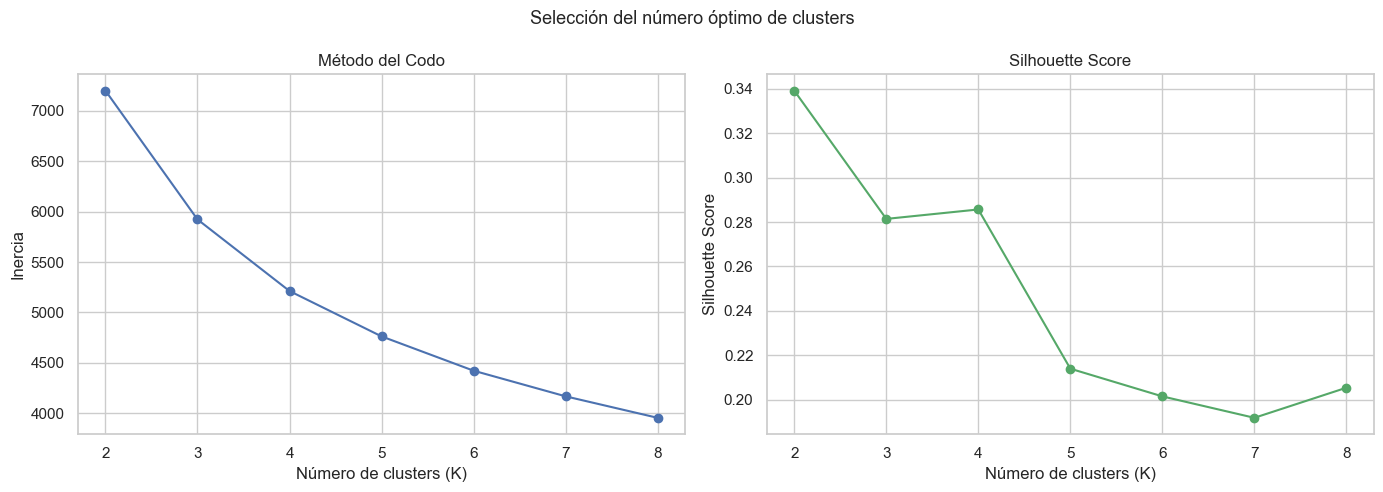

In [71]:
# Método del codo para determinar número óptimo de clusters
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Selección del número óptimo de clusters', fontsize=13)
plt.tight_layout()
plt.show()

In [72]:
# Aplicar K-Means
K_OPTIMO = 3
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=SEED, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Distribución de clusters:')
print(df_cluster['Cluster'].value_counts().sort_index())

Distribución de clusters:
Cluster
0    689
1    235
2    534
Name: count, dtype: int64


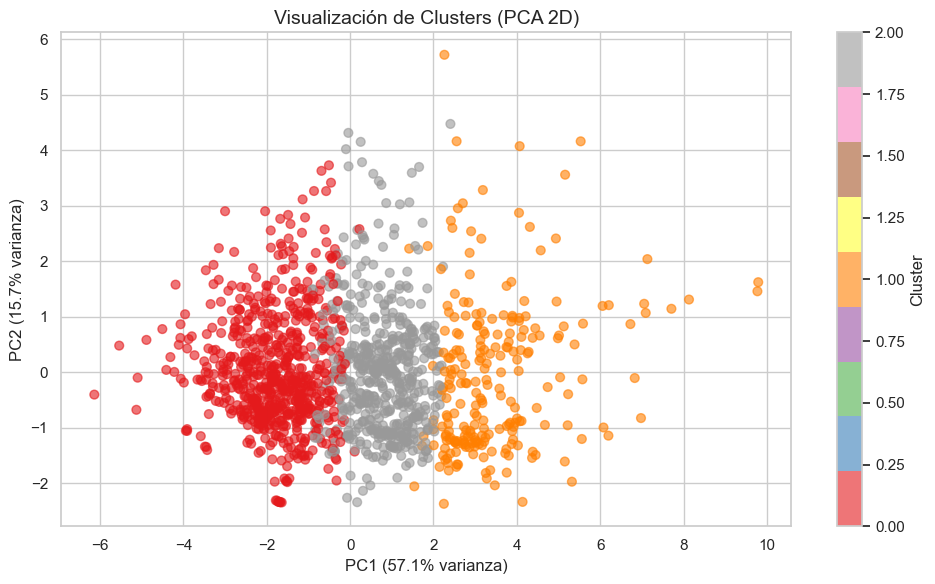

In [73]:
# Visualización de clusters con PCA (reducción a 2D)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_cluster['Cluster'], cmap='Set1', alpha=0.6, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de Clusters (PCA 2D)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.tight_layout()
plt.show()

In [74]:
# Características de cada cluster
print('Características promedio por cluster:')
df_cluster.groupby('Cluster').mean().round(2)

Características promedio por cluster:


,OverallQual,GrLivArea,TotalBsmtSF,GarageArea,YearBuilt,FullBath,TotRmsAbvGrd,SalePrice
Cluster,,,,,,,,
0,5.15,1176.14,860.24,355.83,1951.78,1.08,5.66,128720.92
1,8.03,2185.44,1572.79,745.56,1994.91,2.06,8.22,314423.06
2,6.46,1644.79,1071.70,501.65,1985.88,1.98,6.86,189554.43


C:\Users\eagi5\AppData\Local\Temp\ipykernel_11892\879090888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')


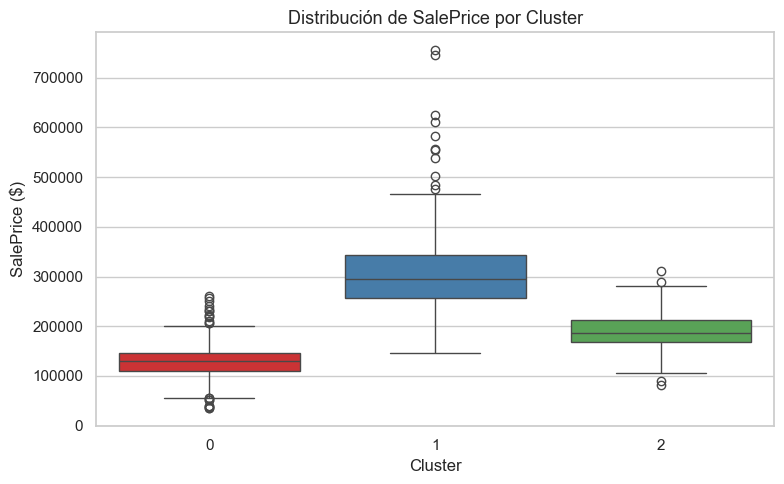

In [75]:
# Boxplot de SalePrice por cluster
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster', y='SalePrice', data=df_cluster, palette='Set1')
plt.title('Distribución de SalePrice por Cluster', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('SalePrice ($)')
plt.tight_layout()
plt.show()

**Descripción de los clusters identificados:**

- **Cluster 0 — Viviendas económicas:** Casas con área habitable y precio bajos, calidad general moderada, pocas habitaciones y garajes pequeños. Representan el segmento de mercado accesible.

- **Cluster 1 — Viviendas de rango medio:** Propiedades con características intermedias en todas las variables. Son las más numerosas y representan el mercado típico.

- **Cluster 2 — Viviendas premium:** Casas grandes, con alta calidad constructiva, garajes amplios y precios significativamente más altos. Representan el segmento de lujo.

Estos grupos son coherentes con la estructura del mercado inmobiliario y sugieren que los modelos predictivos podrían beneficiarse de considerar el segmento de la propiedad como variable adicional.